In [1]:
DATASET_ROOT = "/kaggle/input/datasets/hussamsyed/dataset-transition-v2/dataset_transition_v2"

In [2]:
import os
import json
import random
from pathlib import Path

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms

# =========================
# CONFIG
# =========================
DATASET_ROOT = "/kaggle/input/datasets/hussamsyed/dataset-transition-v2/dataset_transition_v2"
MAX_SAMPLES = 90          # small smoke test
EPOCHS = 3
BATCH_SIZE = 16
LR = 1e-3
IMAGE_SIZE = 64
DVS_SIZE = 64
NUM_WORKERS = 0
SEED = 42

STATE_LABEL_MAP = {"Red": 0, "Yellow": 1, "Green": 2}
TRANSITION_LABEL_MAP = {
    "Red_to_Green": 0,
    "Green_to_Yellow": 1,
    "Yellow_to_Red": 2,
}

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}", flush=True)

# =========================
# FIND SAMPLES
# =========================
def find_samples(dataset_root):
    root = Path(dataset_root)
    samples = []

    for meta_path in root.rglob("meta.json"):
        sample_dir = meta_path.parent

        rgb_path = sample_dir / "roi_rgb.png"
        rgb_seq_path = sample_dir / "rgb_sequence.npy"
        dvs_roi_seq_path = sample_dir / "dvs_roi_sequence.npy"

        if not rgb_path.exists():
            continue
        if not rgb_seq_path.exists():
            continue
        if not dvs_roi_seq_path.exists():
            continue

        with open(meta_path, "r") as f:
            meta = json.load(f)

        if not meta.get("quality_ok", True):
            continue

        state_label = meta.get("state_label")
        transition_label = meta.get("transition_label")

        if state_label not in STATE_LABEL_MAP:
            continue
        if transition_label not in TRANSITION_LABEL_MAP:
            continue

        samples.append({
            "rgb_path": str(rgb_path),
            "rgb_seq_path": str(rgb_seq_path),
            "dvs_roi_seq_path": str(dvs_roi_seq_path),
            "state_label_name": state_label,
            "state_label": STATE_LABEL_MAP[state_label],
            "transition_label_name": transition_label,
            "transition_label": TRANSITION_LABEL_MAP[transition_label],
            "weather_mode": meta.get("weather_mode", "unknown"),
            "speed_kmh": float(meta.get("speed_kmh", 0.0)),
            "traffic_light_id": int(meta.get("traffic_light_id", -1)),
        })

    if not samples:
        raise RuntimeError("No valid samples found. Check DATASET_ROOT.")
    return samples

samples = find_samples(DATASET_ROOT)
print(f"Total valid samples found: {len(samples)}", flush=True)

random.shuffle(samples)
samples = samples[:min(MAX_SAMPLES, len(samples))]
print(f"Mini-test subset size: {len(samples)}", flush=True)

n_train = max(1, int(0.8 * len(samples)))
train_samples = samples[:n_train]
val_samples = samples[n_train:] if len(samples) - n_train > 0 else samples[:1]

print(f"Train samples: {len(train_samples)} | Val samples: {len(val_samples)}", flush=True)

# =========================
# DATASETS
# =========================
class RGBStateDataset(Dataset):
    def __init__(self, samples, train=True):
        self.samples = samples
        if train:
            self.tf = transforms.Compose([
                transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
                transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
                transforms.ToTensor(),
            ])
        else:
            self.tf = transforms.Compose([
                transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
                transforms.ToTensor(),
            ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        item = self.samples[i]
        img = Image.open(item["rgb_path"]).convert("RGB")
        x = self.tf(img)
        y = torch.tensor(item["state_label"], dtype=torch.long)
        return x, y


class DVSTransitionDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def _load_dvs(self, path):
        arr = np.load(path)  # [T, 2, H, W]
        x = torch.from_numpy(arr).float()
        x = torch.log1p(x)
        x = F.interpolate(x, size=(DVS_SIZE, DVS_SIZE), mode="bilinear", align_corners=False)
        t, c, h, w = x.shape
        x = x.view(t * c, h, w)  # [T*2, H, W]
        denom = x.amax(dim=(1, 2), keepdim=True).clamp_min(1e-6)
        x = x / denom
        return x

    def __getitem__(self, i):
        item = self.samples[i]
        x = self._load_dvs(item["dvs_roi_seq_path"])
        y = torch.tensor(item["transition_label"], dtype=torch.long)
        return x, y


class FusionTransitionDataset(Dataset):
    def __init__(self, samples, train=True):
        self.samples = samples
        if train:
            self.tf = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
                transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
                transforms.ToTensor(),
            ])
        else:
            self.tf = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
                transforms.ToTensor(),
            ])

    def __len__(self):
        return len(self.samples)

    def _load_rgb_seq_last(self, path):
        arr = np.load(path)  # [T, H, W, 3]
        frame = arr[-1].astype(np.uint8)
        return self.tf(frame)

    def _load_dvs(self, path):
        arr = np.load(path)  # [T, 2, H, W]
        x = torch.from_numpy(arr).float()
        x = torch.log1p(x)
        x = F.interpolate(x, size=(DVS_SIZE, DVS_SIZE), mode="bilinear", align_corners=False)
        t, c, h, w = x.shape
        x = x.view(t * c, h, w)
        denom = x.amax(dim=(1, 2), keepdim=True).clamp_min(1e-6)
        x = x / denom
        return x

    def __getitem__(self, i):
        item = self.samples[i]
        rgb = self._load_rgb_seq_last(item["rgb_seq_path"])
        dvs = self._load_dvs(item["dvs_roi_seq_path"])
        y = torch.tensor(item["transition_label"], dtype=torch.long)
        return rgb, dvs, y

# =========================
# MODELS
# =========================
class RGBResNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.net = torchvision.models.resnet18(weights=None)
        self.net.fc = nn.Linear(self.net.fc.in_features, num_classes)

    def forward(self, x):
        return self.net(x)


class DVSCNN(nn.Module):
    def __init__(self, in_ch=10, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x).flatten(1)
        return self.fc(x)


class FusionNet(nn.Module):
    def __init__(self, dvs_in_ch=10, num_classes=3):
        super().__init__()
        self.rgb = torchvision.models.resnet18(weights=None)
        self.rgb.fc = nn.Identity()

        self.dvs = nn.Sequential(
            nn.Conv2d(dvs_in_ch, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.head = nn.Sequential(
            nn.Linear(512 + 128, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, rgb, dvs):
        rgb_feat = self.rgb(rgb)
        dvs_feat = self.dvs(dvs).flatten(1)
        fused = torch.cat([rgb_feat, dvs_feat], dim=1)
        return self.head(fused)

# =========================
# TRAIN/VAL HELPERS
# =========================
def accuracy_percent(logits, y):
    preds = logits.argmax(dim=1)
    acc = (preds == y).float().mean().item() * 100.0
    return acc

def run_epoch_rgb(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train(train)
    total_loss, total_acc, total_n = 0.0, 0.0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_percent(logits.detach(), y) * bs
        total_n += bs

    return total_loss / total_n, total_acc / total_n

def run_epoch_dvs(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train(train)
    total_loss, total_acc, total_n = 0.0, 0.0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_percent(logits.detach(), y) * bs
        total_n += bs

    return total_loss / total_n, total_acc / total_n

def run_epoch_fusion(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train(train)
    total_loss, total_acc, total_n = 0.0, 0.0, 0

    for rgb, dvs, y in loader:
        rgb, dvs, y = rgb.to(device), dvs.to(device), y.to(device)
        logits = model(rgb, dvs)
        loss = criterion(logits, y)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_percent(logits.detach(), y) * bs
        total_n += bs

    return total_loss / total_n, total_acc / total_n

# =========================
# RGB STATE MODEL
# =========================
print("\n" + "="*70)
print("MINI TRAINING: RGB STATE MODEL")
print("="*70, flush=True)

rgb_train_ds = RGBStateDataset(train_samples, train=True)
rgb_val_ds = RGBStateDataset(val_samples, train=False)
rgb_train_loader = DataLoader(rgb_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
rgb_val_loader = DataLoader(rgb_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

rgb_model = RGBResNet(num_classes=3).to(device)
rgb_optimizer = torch.optim.Adam(rgb_model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

rgb_best_val = 0.0
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch_rgb(rgb_model, rgb_train_loader, criterion, optimizer=rgb_optimizer)
    va_loss, va_acc = run_epoch_rgb(rgb_model, rgb_val_loader, criterion, optimizer=None)
    rgb_best_val = max(rgb_best_val, va_acc)
    print(
        f"RGB Epoch {epoch:02d} | "
        f"train_loss={tr_loss:.4f} train_acc={tr_acc:.2f}% | "
        f"val_loss={va_loss:.4f} val_acc={va_acc:.2f}%",
        flush=True
    )

# =========================
# DVS TRANSITION MODEL
# =========================
print("\n" + "="*70)
print("MINI TRAINING: DVS TRANSITION MODEL")
print("="*70, flush=True)

dvs_train_ds = DVSTransitionDataset(train_samples)
dvs_val_ds = DVSTransitionDataset(val_samples)
dvs_train_loader = DataLoader(dvs_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
dvs_val_loader = DataLoader(dvs_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

dvs_model = DVSCNN(in_ch=10, num_classes=3).to(device)
dvs_optimizer = torch.optim.Adam(dvs_model.parameters(), lr=LR)

dvs_best_val = 0.0
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch_dvs(dvs_model, dvs_train_loader, criterion, optimizer=dvs_optimizer)
    va_loss, va_acc = run_epoch_dvs(dvs_model, dvs_val_loader, criterion, optimizer=None)
    dvs_best_val = max(dvs_best_val, va_acc)
    print(
        f"DVS Epoch {epoch:02d} | "
        f"train_loss={tr_loss:.4f} train_acc={tr_acc:.2f}% | "
        f"val_loss={va_loss:.4f} val_acc={va_acc:.2f}%",
        flush=True
    )

# =========================
# FUSION TRANSITION MODEL
# =========================
print("\n" + "="*70)
print("MINI TRAINING: FUSION TRANSITION MODEL")
print("="*70, flush=True)

fusion_train_ds = FusionTransitionDataset(train_samples, train=True)
fusion_val_ds = FusionTransitionDataset(val_samples, train=False)
fusion_train_loader = DataLoader(fusion_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
fusion_val_loader = DataLoader(fusion_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

fusion_model = FusionNet(dvs_in_ch=10, num_classes=3).to(device)
fusion_optimizer = torch.optim.Adam(fusion_model.parameters(), lr=LR)

fusion_best_val = 0.0
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch_fusion(fusion_model, fusion_train_loader, criterion, optimizer=fusion_optimizer)
    va_loss, va_acc = run_epoch_fusion(fusion_model, fusion_val_loader, criterion, optimizer=None)
    fusion_best_val = max(fusion_best_val, va_acc)
    print(
        f"FUSION Epoch {epoch:02d} | "
        f"train_loss={tr_loss:.4f} train_acc={tr_acc:.2f}% | "
        f"val_loss={va_loss:.4f} val_acc={va_acc:.2f}%",
        flush=True
    )

# =========================
# FINAL SUMMARY
# =========================
print("\n" + "="*80)
print("MINI TRAINING SUMMARY")
print("="*80)
print(f"{'Model':<15}{'Best Val Accuracy':>20}")
print("-"*80)
print(f"{'RGB State':<15}{rgb_best_val:>19.2f}%")
print(f"{'DVS Transition':<15}{dvs_best_val:>19.2f}%")
print(f"{'Fusion Transition':<15}{fusion_best_val:>19.2f}%")
print("="*80)
print("Done.", flush=True)

Device: cpu
Total valid samples found: 90
Mini-test subset size: 90
Train samples: 72 | Val samples: 18

MINI TRAINING: RGB STATE MODEL
RGB Epoch 01 | train_loss=0.6433 train_acc=75.00% | val_loss=1.2635 val_acc=55.56%
RGB Epoch 02 | train_loss=0.1160 train_acc=95.83% | val_loss=1.1259 val_acc=50.00%
RGB Epoch 03 | train_loss=0.0533 train_acc=97.22% | val_loss=0.7893 val_acc=50.00%

MINI TRAINING: DVS TRANSITION MODEL
DVS Epoch 01 | train_loss=1.0113 train_acc=52.78% | val_loss=1.1424 val_acc=22.22%
DVS Epoch 02 | train_loss=0.8337 train_acc=66.67% | val_loss=1.2026 val_acc=22.22%
DVS Epoch 03 | train_loss=0.6778 train_acc=79.17% | val_loss=1.1546 val_acc=22.22%

MINI TRAINING: FUSION TRANSITION MODEL
FUSION Epoch 01 | train_loss=0.5603 train_acc=77.78% | val_loss=1.2255 val_acc=22.22%
FUSION Epoch 02 | train_loss=0.0358 train_acc=100.00% | val_loss=2.9332 val_acc=22.22%
FUSION Epoch 03 | train_loss=0.0185 train_acc=98.61% | val_loss=4.6533 val_acc=22.22%

MINI TRAINING SUMMARY
Model  

meta files: 90
sample: /kaggle/input/datasets/hussamsyed/dataset-transition-v2/dataset_transition_v2/day_rain__0kmh__Yellow_to_Red/sample_0032/meta.json
state_label: Red
transition_label: Yellow_to_Red
quality_ok: True
rgb_sequence shape: (5, 25, 21, 3)
dvs_roi_sequence shape: (5, 2, 17, 13)


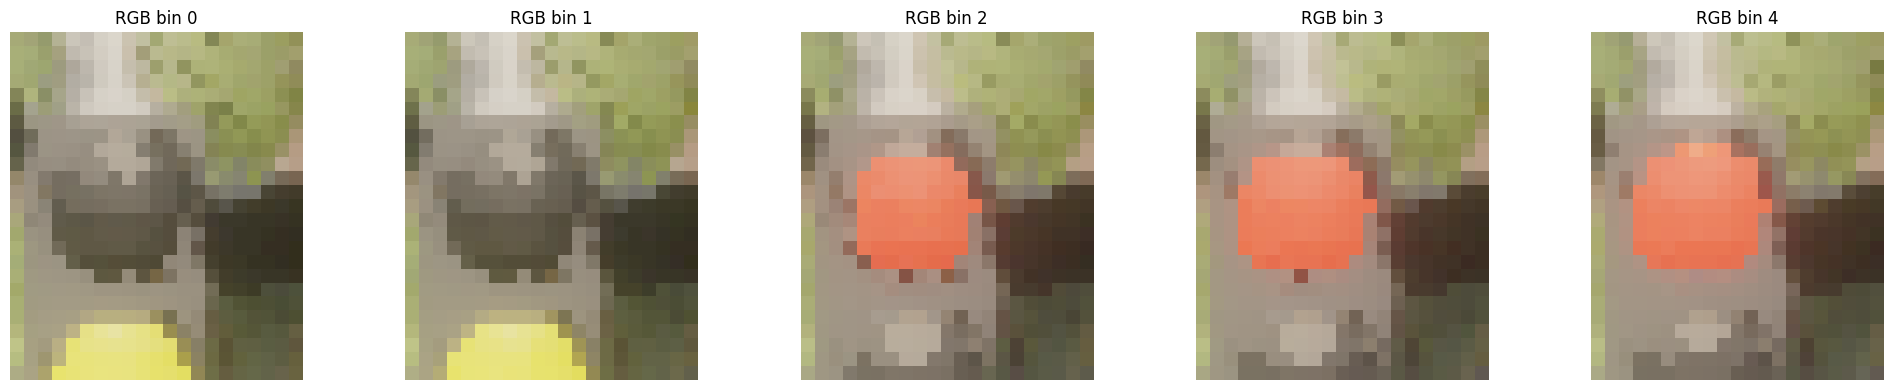

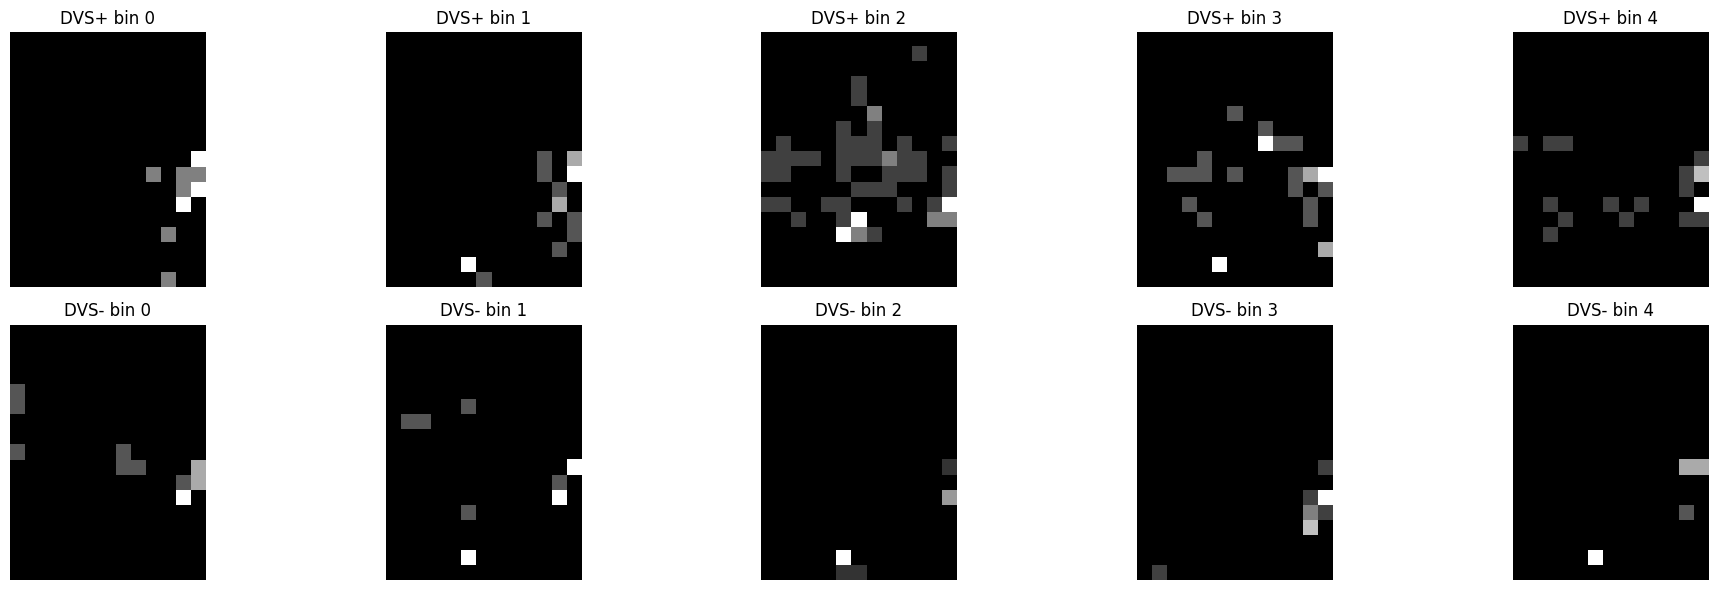

In [3]:
import json
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path("/kaggle/input/datasets/hussamsyed/dataset-transition-v2/dataset_transition_v2")

meta_files = list(ROOT.rglob("meta.json"))
print("meta files:", len(meta_files))

meta_path = random.choice(meta_files)
print("sample:", meta_path)

with open(meta_path, "r") as f:
    meta = json.load(f)

print("state_label:", meta.get("state_label"))
print("transition_label:", meta.get("transition_label"))
print("quality_ok:", meta.get("quality_ok"))

sample_dir = meta_path.parent
rgb_seq = np.load(sample_dir / "rgb_sequence.npy")
dvs_roi_seq = np.load(sample_dir / "dvs_roi_sequence.npy")

print("rgb_sequence shape:", rgb_seq.shape)
print("dvs_roi_sequence shape:", dvs_roi_seq.shape)

# -------- show RGB frames --------
T = rgb_seq.shape[0]
fig, axes = plt.subplots(1, T, figsize=(4*T, 4))
if T == 1:
    axes = [axes]

for i in range(T):
    frame = rgb_seq[i]
    if frame.dtype != np.uint8:
        frame = np.clip(frame, 0, 255).astype(np.uint8)
    axes[i].imshow(frame[:, :, ::-1])  # BGR -> RGB
    axes[i].set_title(f"RGB bin {i}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

# -------- show DVS frames --------
# expected shape [T, 2, H, W]
fig, axes = plt.subplots(2, T, figsize=(4*T, 6))
if T == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for i in range(T):
    pos = dvs_roi_seq[i, 0]
    neg = dvs_roi_seq[i, 1]

    axes[0, i].imshow(pos, cmap="gray")
    axes[0, i].set_title(f"DVS+ bin {i}")
    axes[0, i].axis("off")

    axes[1, i].imshow(neg, cmap="gray")
    axes[1, i].set_title(f"DVS- bin {i}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()